<div style="
    background-color: rgba(17, 11, 11, 0.32);
    padding: 30px;
    width: 90%;
    margin: 40px auto;
    text-align: center;
    border-radius: 20px;
">
    <h1 style="color: #ed1c1c; font-size: 52px; margin: 0;">
        Prédiction du risque d’abandon scolaire
    </h1>
</div>

Réalisé par :
- **KOFFI** Kouamé Jean-Baptiste

# **<span style="color:#46d3c5ff">Introduction et Contexte</span>**

Dans le cadre de la lutte contre l’abandon scolaire, les établissements d’enseignement ont besoin d’outils simples, fiables et rapides pour identifier les étudiants en situation de difficulté.
Ce mini-projet s’inscrit dans une logique de **besoin métier**, où l’objectif principal n’est pas seulement de **concevoir un modèle de Machine Learning capable de prédire le risque d’abandon scolaire d’un étudiant**, à partir de données académiques et comportementales., mais également orienté vers une **future utilisation dans une application de prédiction accessible à des utilisateurs**.

L’idée est de mettre à disposition des responsables pédagogiques, enseignants et administrations **un outil capable d’anticiper les situations à risque** afin d’améliorer le suivi académique et de renforcer la réussite scolaire.
Cette solution devra permettre de :

* collecter les informations relatives à un étudiant
* analyser automatiquement son profil
* estimer le niveau de risque d’abandon
* faciliter la mise en place d’actions préventives

À terme, cette logique sera intégrée dans une **application web simple et intuitive**, dans laquelle l’utilisateur pourra saisir les données d’un étudiant et obtenir immédiatement une prédiction claire , par exemple :

* **Étudiant à faible risque**
* **Étudiant à risque élevé d’abandon**


# **<span style="color:#46d3c5ff"> Présentation des Données</span>**

In [1]:

import pandas as pd
data=pd.read_csv("student_dropout_dataset.csv")
data

,age,gender,average_grade,absenteeism_rate,internet_access,study_time_hours,extra_activities,dropout_risk
0,21,Male,16.27,0.35,Yes,4.1,No,0
1,18,Female,12.30,0.38,No,0.2,No,1
2,22,Male,8.10,0.04,No,3.4,No,0
3,19,Male,13.84,0.25,No,4.8,Yes,0
4,21,Female,14.62,0.47,Yes,0.6,Yes,1
...,...,...,...,...,...,...,...,...
295,15,Female,17.58,0.04,Yes,3.6,No,0
296,19,Male,14.24,0.00,Yes,0.1,Yes,0
297,20,Male,7.59,0.48,No,1.7,No,1
298,17,Female,14.57,0.00,Yes,4.1,Yes,0


In [2]:
data.describe()

,age,average_grade,absenteeism_rate,study_time_hours,dropout_risk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,19.326667,11.600067,0.257633,2.516000,0.243333
std,2.873001,3.705599,0.138460,1.341321,0.429812
min,15.000000,5.030000,0.000000,0.000000,0.000000
25%,17.000000,8.440000,0.147500,1.400000,0.000000
50%,19.000000,11.755000,0.260000,2.600000,0.000000
75%,22.000000,14.640000,0.380000,3.525000,0.000000
max,24.000000,17.960000,0.500000,5.000000,1.000000




## Source et Structure

Le jeu de données utilisé pour ce projet est un fichier CSV nommé `student_dropout_dataset.csv`. 
Il contient **300 observations** d'étudiants, décrites par **7 variables explicatives** et **1 variable cible**.

| Variable | Type | Description | Valeurs possibles |
| :--- | :---: | :--- | :--- |
| `age` | numérique | Âge de l'étudiant | 15 - 24 ans |
| `gender` | Catégorielle | Sexe | Male / Female |
| `average_grade` | numérique| Moyenne générale | 5.03 - 17.96 (/20) |
| `absenteeism_rate` | numérique| Taux d'absentéisme | 0.00 - 0.50 (0 à 50%) |
| `internet_access` | Catégorielle| Accès Internet à domicile | Yes / No |
| `study_time_hours` | numérique | Heures d'étude par jour | 0.0 - 5.0 heures |
| `extra_activities` | Catégorielle | Activités extrascolaires | Yes / No |
| `dropout_risk` | **Cible** | Risque d'abandon scolaire | **1** = À risque / **0** = Sans risque |

##  Logique de Construction de la Cible

La variable `dropout_risk`(Risque d'abandon scolaire) n'a pas été attribuée au hasard. Elle suit une **règle métier explicite** qui reflète les critères généralement surveillés par les équipes pédagogiques.

Un étudiant est classé **"À Risque" (1)** s'il remplit **au moins 2** des **3 conditions** suivantes :

| Critère | Seuil | Signification pédagogique |
| :--- | :---: | :--- |
| ① Moyenne faible | `< 10/20` | Difficultés académiques avérées |
| ② Absentéisme élevé | `> 30%` | Désengagement scolaire |
| ③ Temps d'étude insuffisant | `< 1h/jour` | Manque de travail personnel |

## Aperçu de la Distribution des Classes
Le jeu de données présente un **déséquilibre modéré** entre les deux classes :

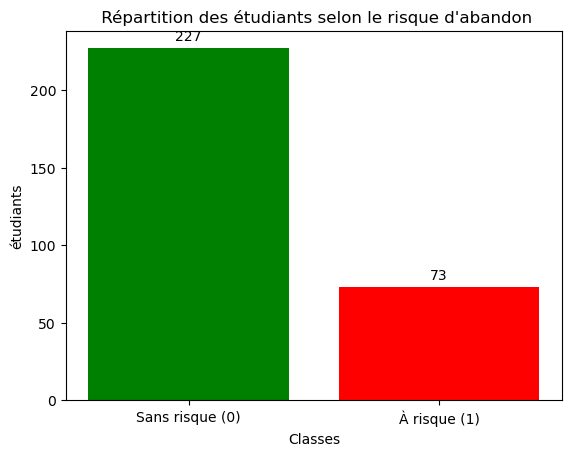

In [3]:
import numpy as np
import matplotlib.pyplot as plt


labels = data["dropout_risk"]   

# Comptage des classes
classes = ['Sans risque (0)', 'À risque (1)']
counts = [
    np.sum(labels == 0),
    np.sum(labels == 1)
]

# Couleurs associées
colors = ['green', 'red']

# 📊 Diagramme en barres
plt.bar(classes, counts, color=colors)

plt.title(" Répartition des étudiants selon le risque d'abandon")
plt.ylabel("étudiants")
plt.xlabel("Classes")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

 Ce déséquilibre  devra être pris en compte lors de l'évaluation du modèle. On privilégiera des métriques comme le **F1-score** plutôt que la simple précision globale(accuracy).

 
# **<span style="color:#46d3c5ff"> Prétraitement et Analyse exploratoire  des données</span>**

In [ ]:
import seaborn as sns


# Configuration de l'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Pour des graphiques en haute résolution
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100


# **Data Cleaning**

In [42]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Valeurs manquantes par colonne:")
print(data.isnull().sum())


numeric_cols = ['age', 'average_grade', 'absenteeism_rate', 'study_time_hours']

categorical_cols = ['gender', 'internet_access', 'extra_activities']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


features = preprocessor.fit_transform(data)

feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
)

features= pd.DataFrame(features, columns=feature_names)

features.head(10)

Valeurs manquantes par colonne:
age                 0
gender              0
average_grade       0
absenteeism_rate    0
internet_access     0
study_time_hours    0
extra_activities    0
dropout_risk        0
dtype: int64


,age,average_grade,absenteeism_rate,study_time_hours,gender_Female,gender_Male,internet_access_No,internet_access_Yes,extra_activities_No,extra_activities_Yes
0,0.583407,1.262343,0.668212,1.182899,0.0,1.0,0.0,1.0,1.0,0.0
1,-0.462542,0.189201,0.885243,-1.729541,1.0,0.0,1.0,0.0,1.0,0.0
2,0.932057,-0.946113,-1.574435,0.660153,0.0,1.0,1.0,0.0,1.0,0.0
3,-0.113892,0.605483,-0.055222,1.705644,0.0,1.0,1.0,0.0,0.0,1.0
4,0.583407,0.816327,1.536334,-1.430830,1.0,0.0,0.0,1.0,0.0,1.0
5,1.629356,-0.946113,-0.706313,1.481611,0.0,1.0,0.0,1.0,1.0,0.0
6,-0.811191,-0.456847,0.306495,0.361441,0.0,1.0,0.0,1.0,1.0,0.0
7,0.583407,0.094591,-0.561626,0.436119,0.0,1.0,1.0,0.0,1.0,0.0
8,0.932057,-0.037862,-0.199909,0.436119,1.0,0.0,1.0,0.0,0.0,1.0
9,-0.113892,-0.413597,0.089465,-0.758728,0.0,1.0,0.0,1.0,0.0,1.0


Le dataset ne contient aucune valeur manquante.

Les variables catégorielles ont été encodées en 0/1 via One-Hot Encoding et les variables numériques ont été normalisées par Z-score.
 
Données numériques normalisées et catégorielles encodées concaténées en un seul dataset homogène des variables explicatives prêt à être modélisé.

# **EDA**

### **Histogrammes (variables numériques)**

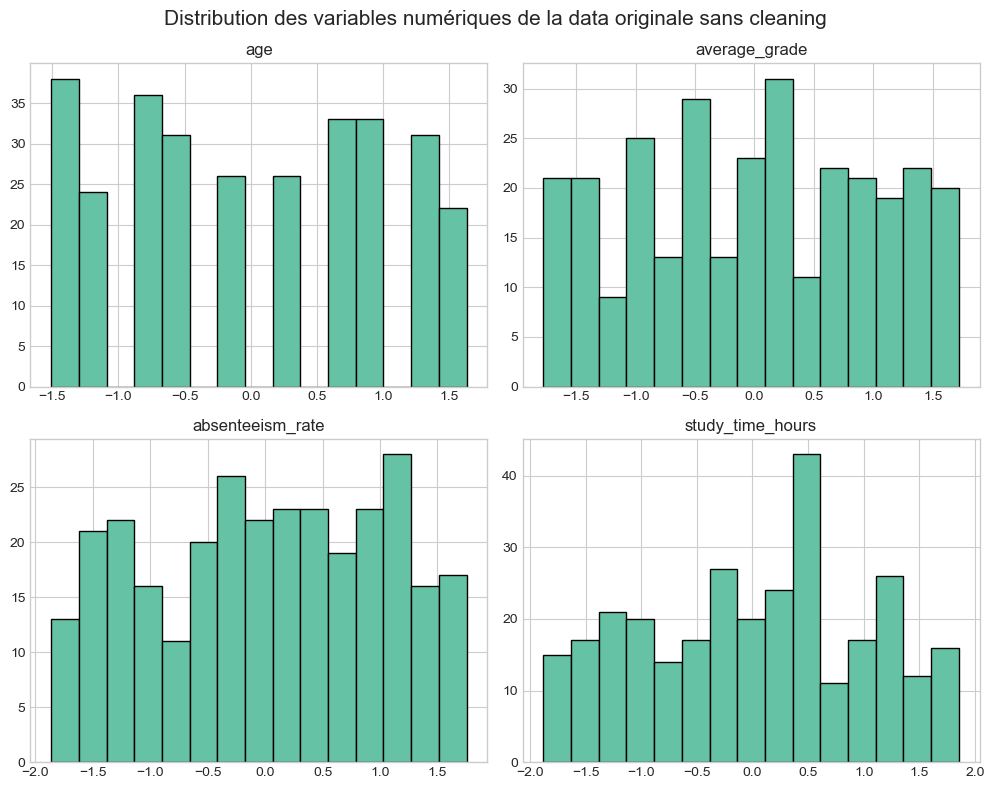

In [33]:
import matplotlib.pyplot as plt

data_num =features[['age', 'average_grade', 'absenteeism_rate', 'study_time_hours']]

# Histogrammes propres
data_num.hist(figsize=(10, 8), bins=15,edgecolor="black")

plt.suptitle("Distribution des variables numériques de la data originale sans cleaning", fontsize=15)
plt.tight_layout()
plt.show()

### **Matrice de corrélation et variables influentes** 

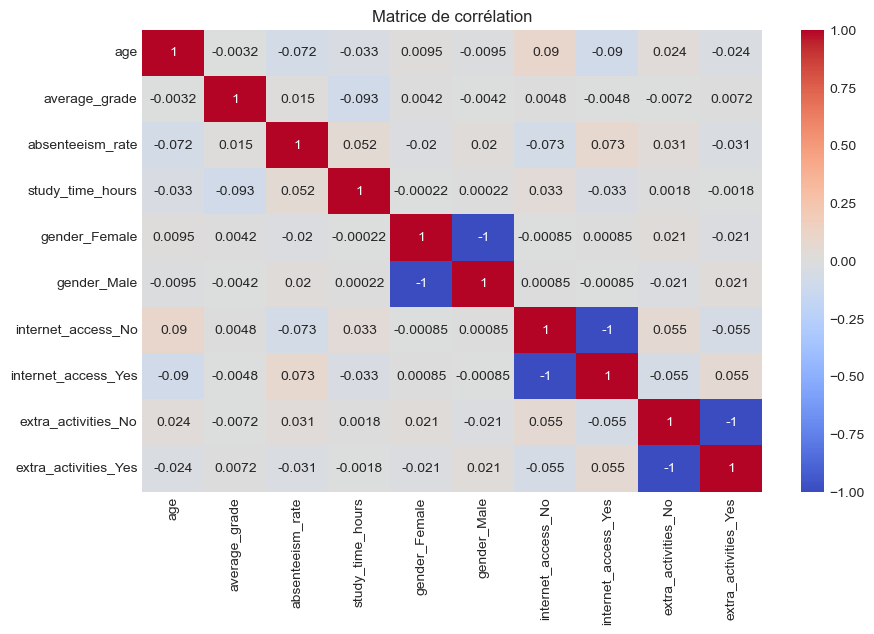

Corrélation avec dropout_risk :
absenteeism_rate        0.412653
gender_Female           0.051519
internet_access_Yes     0.029846
extra_activities_No     0.013273
extra_activities_Yes   -0.013273
internet_access_No     -0.029846
age                    -0.032086
gender_Male            -0.051519
study_time_hours       -0.297416
average_grade          -0.384622
Name: dropout_risk, dtype: float64


In [34]:
import seaborn as sns

corr = features.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


# Ajouter la cible pour voir sa corrélation avec les features
features_with_target = features.copy()
features_with_target['dropout_risk'] = data['dropout_risk']

# Calculer la corrélation avec dropout_risk uniquement
target_corr = features_with_target.corr()['dropout_risk'].drop('dropout_risk').sort_values(ascending=False)

print("Corrélation avec dropout_risk :")
print(target_corr)


Les corrélations avec **dropout_risk(la variable cible)** montrent que seules trois variables ont une influence significative : **absenteeism_rate (+0.41), average_grade (-0.38) et study_time_hours (-0.29)**. 

Les autres variables **(age, gender, internet_access, extra_activities)** affichent des corrélations **inférieures à 0.06** et peuvent être  négligé.

### **Nombre d'abandon par sexe**

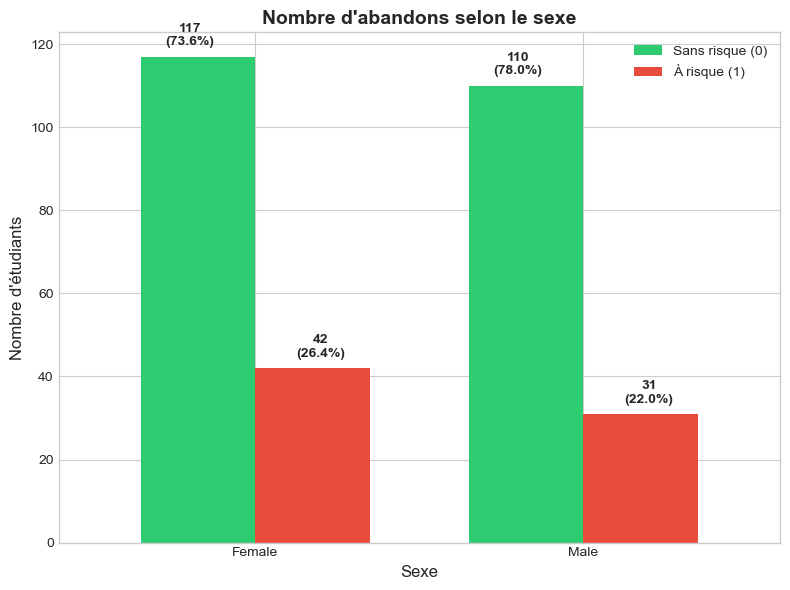

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Compter le nombre d'abandons par sexe
abandon_par_sexe = data.groupby('gender')['dropout_risk'].value_counts().unstack()

# Calculer les pourcentages
pct_par_sexe = abandon_par_sexe.div(abandon_par_sexe.sum(axis=1), axis=0) * 100


# Graphique
ax = abandon_par_sexe.plot(kind='bar', figsize=(8, 6), color=['#2ecc71', '#e74c3c'], width=0.7)

plt.title("Nombre d'abandons selon le sexe", fontsize=14, fontweight='bold')
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Nombre d'étudiants", fontsize=12)
plt.legend(['Sans risque (0)', 'À risque (1)'], loc='upper right')
plt.xticks(rotation=0)

# Ajouter les valeurs (nombres) au-dessus des barres
for i, (index, row) in enumerate(abandon_par_sexe.iterrows()):
    cumsum = 0
    for j, (col, val) in enumerate(row.items()):
        if val > 0:
            pct = pct_par_sexe.loc[index, col]
            plt.text(i + (j-0.5)*0.4, val + 2, f'{val}\n({pct:.1f}%)', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Sur 159 femmes, 42 sont à risque (soit 26,4%). Sur 141 hommes, 31 sont à risque (soit 22,0%). La différence est faible et confirme que le sexe n'est pas un facteur déterminant du risque d'abandon

# **FEATURE ENGINEERING**

In [37]:


# Création du taux de présence (à partir des données originales non normalisées)
features['ratio_presence_absence'] = (1 - data['absenteeism_rate'])/ data["absenteeism_rate"]
features["ratio_presence_absence"] = features["ratio_presence_absence"].replace([np.inf, -np.inf], np.nan).fillna(features["ratio_presence_absence"].median())


# Création du score de risque (à partir des données originales non normalisées)
features['score_global'] = (
    (data['average_grade'] < 10).astype(int) +
    (data['absenteeism_rate'] > 0.3).astype(int) +
    (data['study_time_hours'] < 1).astype(int)
)

# Normalisation des nouvelles colonnes pour rester cohérent

scaler = StandardScaler()
features[['ratio_presence_absence', 'score_global']] = scaler.fit_transform(features[['ratio_presence_absence', 'score_global']])

print("Nouvelles colonnes ajoutées et normalisées :")

features[['ratio_presence_absence', 'score_global']].head(10)


Nouvelles colonnes ajoutées et normalisées :


,ratio_presence_absence,score_global
0,-0.408911,0.093037
1,-0.429640,1.361720
2,1.625959,0.093037
3,-0.303886,-1.175646
4,-0.475949,1.361720
5,-0.097117,0.093037
6,-0.365151,0.093037
7,-0.160934,-1.175646
8,-0.271921,-1.175646
9,-0.331115,-1.175646


Deux nouvelles variables ont été créées :

* ratio_presence_absence : mesure le rapport entre présence et absence

  (1 - absenteeism_rate) / absenteeism_rate

  plus la valeur est élevée, plus l’étudiant est présent.

* score_global : score de risque basé sur 3 critères
  (moyenne < 10, absentéisme > 30%, temps d’étude < 1h)

   varie de 0 à 3.

Ces variables ont ensuite été normalisées (Z-score) pour assurer la cohérence avec les autres variables du dataset.



### **variables importantes** 

In [38]:
# Ajouter la cible pour l'analyse
features_with_target = features.copy()
features_with_target['dropout_risk'] = data['dropout_risk']

# Nouvelle matrice de corrélation
corr_new = features_with_target.corr()

# Afficher uniquement les corrélations avec dropout_risk
target_corr_new = corr_new['dropout_risk'].drop('dropout_risk').sort_values(key=abs, ascending=False)

print("Corrélations avec dropout_risk (après Feature Engineering) :")
print(target_corr_new)


Corrélations avec dropout_risk (après Feature Engineering) :
score_global              0.821489
absenteeism_rate          0.412653
average_grade            -0.384622
study_time_hours         -0.297416
ratio_presence_absence   -0.200171
gender_Male              -0.051519
gender_Female             0.051519
age                      -0.032086
internet_access_No       -0.029846
internet_access_Yes       0.029846
extra_activities_Yes     -0.013273
extra_activities_No       0.013273
Name: dropout_risk, dtype: float64


Le **score_global** est la variable la plus corrélée à la cible **(+0.82)**, suivi du taux d’absentéisme (+0.41), de la moyenne (-0.38) et du temps d’étude (-0.29).D'où **les plus importantes**

Le **ratio_presence_absence**(une nouvelle variable ajoutée) est moins corrélé (-0.20) mais reste cohérent avec le phénomène étudié.


# **<span style="color:#46d3c5ff"> Modélisation</span>**

`score_global` et `ratio_presence_absence` 

Ces deux variables ont été créées lors du Feature Engineering mais **ne seront pas  conservées** pour l'entraînement du modèle.

**`score_global`** : Cette variable était construite à partir des **mêmes règles** qui ont servi à générer la cible `dropout_risk` (moyenne < 10, absentéisme > 30%, étude < 1h). La conserver aurait introduit une **fuite de données (data leakage)** : le modèle aurait obtenu artificiellement 100% de performance sans rien apprendre de réel. En situation réelle, on ne dispose pas d'un score pré-calculé, le modèle doit l'apprendre seul.

**` Le  ratio_presence_absence`** : est une transformation directe du **absenteeism_rate**. Il est donc redondant et n’apporte pas d’information nouvelle au modèle, puisqu’il exprime la même information sous une forme inversée.

**Donc** : Supprimer ces deux variables garantit un apprentissage **honnête et réaliste**, basé uniquement sur les données brutes disponibles en conditions réelles.

Train: 240 échantillons
Test : 60 échantillons

Performances des modèles de base :
                Modèle  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.867      0.733   0.733     0.733
1        Random Forest     0.983      1.000   0.933     0.966
2                  SVM     0.883      0.833   0.667     0.741

Validation croisée (5-fold) :
Logistic Regression: F1 moyen = 0.763
Random Forest: F1 moyen = 0.947
SVM: F1 moyen = 0.748
MATRICES DE CONFUSION DES 3 MODÈLES DE BASE


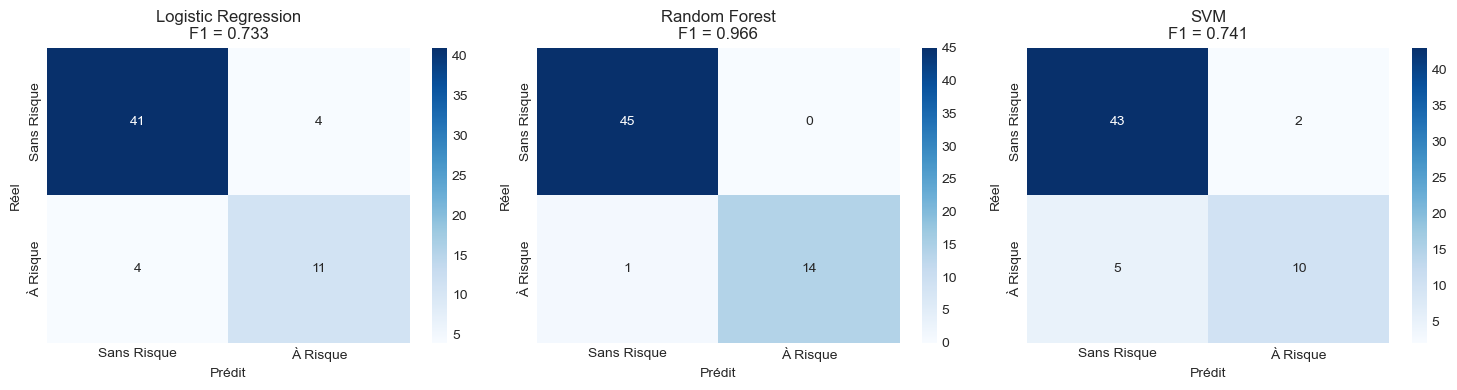

In [39]:

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Préparation des données

X = features.drop([ 'ratio_presence_absence','score_global'], axis=1)
y = data['dropout_risk']

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} échantillons")
print(f"Test : {X_test.shape[0]} échantillons")

print("==============================================")
# 6. Modélisation - Modèles de base

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Entraînement et évaluation
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print("\nPerformances des modèles de base :")
print(results_df.round(3))


# 7. Validation croisée (5-fold)
print("==============================================")
print("\nValidation croisée (5-fold) :")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='f1')
    print(f"{name}: F1 moyen = {cv_scores.mean():.3f}")




# MATRICES DE CONFUSION DES 3 MODÈLES DE BASE
print("==============================================")
print("MATRICES DE CONFUSION DES 3 MODÈLES DE BASE")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Sans Risque', 'À Risque'],
                yticklabels=['Sans Risque', 'À Risque'],
                ax=ax)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(f'{name}\nF1 = {f1_score(y_test, y_pred):.3f}')

plt.tight_layout()
plt.show()

Le **Random Forest** domine nettement avec un **F1-score de 0.966** et une validation croisée stable **à 0.947**. Sa matrice de confusion montre seulement 1 faux négatif (étudiant à risque non détecté) et 0 faux positif(détecter tous les sans risque). 

La **Logistic Regression** et **le SVM** sont moins performants avec davantage d'erreurs.

Conclusion : Random Forest est retenu pour l'optimisation.


 Optimisation du Random Forest...

Meilleurs paramètres : {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Meilleur F1-score (CV) : 0.983

 Performances après optimisation :
Accuracy  : 0.983
Precision : 1.000
Recall    : 0.933
F1-score  : 0.966


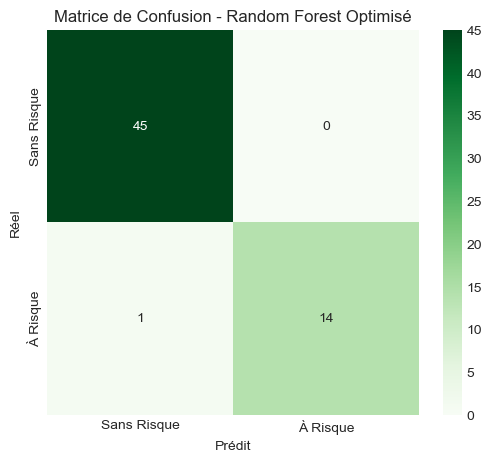

In [40]:

# OPTIMISATION - GRID SEARCH (RANDOM FOREST)


print("\n Optimisation du Random Forest...")

param_grid = {
    'n_estimators': [50, 100, 250],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=10, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur F1-score (CV) : {grid_search.best_score_:.3f}")

# Évaluation sur le test
best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test)

print("\n Performances après optimisation :")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_opt):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_opt):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_opt):.3f}")
print(f"F1-score  : {f1_score(y_test, y_pred_opt):.3f}")

# Matrice de confusion optimisée
cm_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sans Risque', 'À Risque'],
            yticklabels=['Sans Risque', 'À Risque'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Random Forest Optimisé')
plt.show()



Après optimisation, le modèle obtient d'excellents résultats :

- Il identifie correctement **14 étudiants à risque sur 15**.
- Il **ne signale jamais à tort** un étudiant qui va bien (aucune fausse alerte).
- Sa fiabilité globale est de **98,3%**.

Autrement dit, quand le modèle dit "À Risque", on peut avoir confiance : l'étudiant a vraiment besoin d'un suivi.

In [41]:
import joblib

# 1. Modèle optimisé
joblib.dump(best_rf, 'model_dropout.pkl')
joblib.dump(preprocessor, "preprocessor.pkl")



['preprocessor.pkl']

Ces éléments ont été sauvegardés afin d’assurer la reproductibilité et le bon fonctionnement du modèle dans l’application :

* Modèle (model_dropout.pkl) : permet de réutiliser le modèle entraîné sans le réentraîner.
* Scaler (preprocessor.pkl):permet d'utiliser les memes transformation


# **<span style="color:#46d3c5ff"> Conclusion générale</span>**


Ce projet a permis de développer un **modèle prédictif fiable** du risque d'abandon scolaire, basé sur des données académiques et comportementales simples à collecter (moyenne, absentéisme, temps d'étude).

Le **Random Forest optimisé** atteint une performance de **98,3% de précision globale**, avec une capacité à détecter **93% des étudiants à risque** sans générer de fausses alertes. Les trois facteurs clés identifiés confirment l'intuition pédagogique : résultats scolaires faibles, absences répétées et manque de travail personnel.


Le modèle est désormais prêt à être intégré dans une **application web** (Flask), offrant aux équipes pédagogiques un outil simple et rapide pour anticiper les décrochages et mettre en place des actions de soutien ciblées.
